<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/BIY7121_Entrega3_G1v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 3: Modelos de Clasificación y Segmentación
**Asignatura:** BIY7121 - Minería de Datos &nbsp;·&nbsp; **Grupo:** 1

**Autores:** Rodrigo Casanova, José Vásquez, Samuel Acuña

**Correos:** rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl

**Fecha de creación:** Junio 2026

**Versión:** 3.0

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, silhouette_score)
from sklearn.inspection import permutation_importance

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
sb.set_style("whitegrid")

!pip install kneed -q
from kneed import KneeLocator

## Contexto y objetivo del proyecto

Una empresa de construcción que opera en ciudades como Concepción, Valdivia, Temuco y Punta Arenas busca optimizar la planificación de sus obras considerando las condiciones climáticas.

A partir del análisis de variables como precipitaciones, humedad, nubosidad, viento y temperatura, la empresa ajusta sus cronogramas de trabajo para reducir retrasos y mejorar la eficiencia operativa. En esta entrega se abordan dos tareas:

1. **Clasificación:** predecir si una hora determinada será lluviosa (`is_rainy_hour`), construyendo un modelo funcional que solo utiliza información disponible al momento de la predicción.
2. **Segmentación:** agrupar las observaciones climáticas en perfiles operativos que apoyen la toma de decisiones de planificación.

> **Nota sobre la variable objetivo:** la rúbrica la nombra `is_rain_hour`; en el dataset la columna real es `is_rainy_hour`, que es la utilizada durante todo el desarrollo.

## Carga del conjunto de datos

In [2]:
!wget -q https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv

data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory=False)
print("Dimensiones:", data.shape)
data.head()

Dimensiones: (33024, 15)


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,33024.0,10.644075,5.213359,-5.100000,7.050000,10.400000,13.700000,31.750000
relative_humidity_2m,33024.0,79.042842,16.228987,15.230701,68.349886,82.217838,92.891105,100.000000
apparent_temperature,33024.0,8.337603,6.350746,-8.741941,3.876656,8.232820,12.350445,32.108310
precipitation,33024.0,0.138981,0.582210,0.000000,0.000000,0.000000,0.000000,13.200000
cloud_cover,33024.0,62.114977,41.871036,0.000000,13.000000,88.000000,100.000000,100.000000
wind_speed_10m,33024.0,11.930189,8.474665,0.000000,5.649248,9.940824,15.882896,65.250920
wind_direction_10m,33024.0,205.227225,101.410042,0.367278,139.531913,229.398790,284.036250,360.000000
rain,33024.0,0.136601,0.577866,0.000000,0.000000,0.000000,0.000000,13.200000
is_day,33024.0,0.495882,0.499991,0.000000,0.000000,0.000000,1.000000,1.000000
sunshine_duration,33024.0,1221.216663,1650.360797,0.000000,0.000000,0.000000,3600.000000,3600.000000


In [5]:
correlaciones = data.corr(numeric_only=True)

correlacion_objetivo = correlaciones["is_rainy_hour"].sort_values(
    ascending=False
)

correlacion_objetivo

,is_rainy_hour
is_rainy_hour,1.000000
precipitation,0.498582
rain,0.496635
cloud_cover,0.327969
relative_humidity_2m,0.245598
wind_speed_10m,0.186934
longitud,0.029535
is_day,0.027955
wind_direction_10m,0.008850
temperature_2m,-0.054811


### Interpretación:

Se calculó la correlación de las variables numéricas con la variable objetivo `is_rainy_hour`, con el fin de apoyar la selección de variables predictoras.

Se observa que las variables `precipitation` y `rain` presentan la mayor correlación con el objetivo, seguidas por la nubosidad y la humedad relativa. Si bien `precipitation` y `rain` parecen las más informativas, más adelante se verifica que ambas definen directamente la variable objetivo, por lo que no pueden utilizarse como predictoras.

La selección final de variables no se basa únicamente en la correlación, sino también en el criterio de funcionalidad del modelo y en la necesidad de evitar fuga de datos.

# Fase 3 - Preparación de datos

Antes de modelar se revisan duplicados, valores nulos e inconsistencias, y se derivan las variables temporales necesarias para que el modelo sea funcional.

## Identificación de valores duplicados

In [6]:
print("Filas duplicadas:", data.duplicated().sum())

Filas duplicadas: 0


### Interpretación:

Se revisó la existencia de registros duplicados dentro del conjunto de datos. El resultado indica que no existen filas repetidas, por lo que no fue necesario eliminar registros por duplicidad.

Este hallazgo es importante, ya que permite asegurar que el modelo no será entrenado con observaciones repetidas que puedan sesgar el aprendizaje.

## Identificación de valores nulos

In [7]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


### Interpretación:

Se revisó la existencia de valores nulos en todas las columnas del conjunto de datos. Los resultados muestran que no existen valores faltantes en el dataset original.

A pesar de esto, se mantiene un tratamiento de nulos dentro del pipeline mediante imputación, ya que esto permite que el modelo sea más robusto en caso de recibir nuevos datos con valores faltantes.

## Derivación de la hora y el mes (modelo funcional)

La columna `date` viene en horario UTC. Para que la hora represente correctamente el ciclo diario local de cada localidad, se convierte a la zona horaria de Chile (`America/Santiago`) y recién entonces se extraen `hora` y `mes`.

In [8]:
data["date"] = pd.to_datetime(data["date"], utc=True)
data["date_local"] = data["date"].dt.tz_convert("America/Santiago")

data["hora"] = data["date_local"].dt.hour
data["mes"]  = data["date_local"].dt.month

data[["date", "date_local", "hora", "mes"]].head()

,date,date_local,hora,mes
0,2025-01-01 03:00:00+00:00,2025-01-01 00:00:00-03:00,0,1
1,2025-01-01 04:00:00+00:00,2025-01-01 01:00:00-03:00,1,1
2,2025-01-01 05:00:00+00:00,2025-01-01 02:00:00-03:00,2,1
3,2025-01-01 06:00:00+00:00,2025-01-01 03:00:00-03:00,3,1
4,2025-01-01 07:00:00+00:00,2025-01-01 04:00:00-03:00,4,1


### Interpretación:

A partir de la columna `date`, originalmente en horario UTC, se realizó la conversión a la zona horaria local (`America/Santiago`) antes de extraer la `hora` y el `mes`. Esto permite que la hora represente el momento real del día en cada ciudad y no un valor desplazado por el huso horario.

Estas variables son conocidas al momento de realizar la predicción, por lo que no introducen información futura ni fuga de datos. Más adelante se transforman de forma cíclica para representar correctamente su comportamiento temporal.

## Tratamiento de inconsistencias

In [9]:
def tratar_inconsistencias(df):
    df = df.copy()

    # 1. Valores negativos en variables donde no deberían existir
    columnas_no_negativas = [
        "precipitation", "rain", "cloud_cover",
        "wind_speed_10m", "sunshine_duration", "relative_humidity_2m"
    ]
    for col in columnas_no_negativas:
        if col in df.columns:
            n = (df[col] < 0).sum()
            if n > 0:
                print(f"{col}: {n} valores negativos reemplazados por NaN")
                df[col] = df[col].where(df[col] >= 0, np.nan)

    # 2. Humedad y nubosidad fuera de rango [0, 100]
    for col in ["relative_humidity_2m", "cloud_cover"]:
        if col in df.columns:
            mask = (df[col] < 0) | (df[col] > 100)
            if mask.sum() > 0:
                print(f"{col}: {mask.sum()} valores fuera de rango reemplazados por NaN")
                df.loc[mask, col] = np.nan

    # 3. Dirección del viento fuera de rango [0, 360]
    if "wind_direction_10m" in df.columns:
        mask = (df["wind_direction_10m"] < 0) | (df["wind_direction_10m"] > 360)
        if mask.sum() > 0:
            print(f"wind_direction_10m: {mask.sum()} valores fuera de rango reemplazados por NaN")
            df.loc[mask, "wind_direction_10m"] = np.nan

    # 4. Variables binarias fuera de {0, 1}
    for col in ["is_day", "is_rainy_hour"]:
        if col in df.columns:
            mask = ~df[col].isin([0, 1])
            if mask.sum() > 0:
                print(f"{col}: {mask.sum()} valores no binarios reemplazados por NaN")
                df.loc[mask, col] = np.nan

    return df


data = tratar_inconsistencias(data)
print("Tratamiento de inconsistencias finalizado.")

Tratamiento de inconsistencias finalizado.


### Interpretación:

Se aplicó un tratamiento de inconsistencias considerando reglas propias del contexto climático. Para variables como humedad relativa y nubosidad se validó que sus valores estuvieran entre 0 y 100. Para la dirección del viento se validó el rango entre 0 y 360 grados. Además, se revisó que las variables binarias mantuvieran únicamente los valores 0 y 1.

En caso de encontrar valores fuera de rango, estos fueron reemplazados por NaN para que posteriormente fueran tratados por el imputador definido dentro del pipeline. Esta decisión permite mantener un flujo de preparación consistente y evita eliminar registros completos cuando solo una variable presenta un valor inválido.

No se consideró la temperatura negativa como inconsistencia, ya que en datos meteorológicos puede representar una condición climática real, especialmente en zonas como Punta Arenas.

## Identificación de valores atípicos

In [10]:
def buscar_atipicos(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]


columnas_atipicos = [
    "temperature_2m", "relative_humidity_2m", "cloud_cover",
    "wind_speed_10m", "wind_direction_10m", "sunshine_duration"
]

resumen_atipicos = {c: buscar_atipicos(data, c).shape[0] for c in columnas_atipicos}
pd.DataFrame.from_dict(resumen_atipicos, orient="index", columns=["Cantidad Atípicos"])

,Cantidad Atípicos
temperature_2m,476
relative_humidity_2m,130
cloud_cover,0
wind_speed_10m,1241
wind_direction_10m,0
sunshine_duration,0


### Interpretación:

Se identificaron valores atípicos mediante el método del rango intercuartílico. Se observan valores extremos principalmente en la velocidad del viento y, en menor medida, en la temperatura y la humedad relativa.

En este contexto, los valores atípicos no necesariamente representan errores, ya que pueden corresponder a eventos climáticos reales. Por esta razón, no se eliminaron directamente. En su lugar, se aplica winsorización dentro del pipeline para reducir su impacto sin perder registros del conjunto de datos.

## Transformación cíclica de hora y mes

Las variables temporales son circulares: las 23:00 están cerca de las 00:00, y diciembre está cerca de enero. Representarlas con un único número rompería esa cercanía.

In [11]:
data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

data[["hora", "hora_sin", "hora_cos", "mes", "mes_sin", "mes_cos"]].head()

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,0,0.000000,1.000000,1,0.5,0.866025
1,1,0.258819,0.965926,1,0.5,0.866025
2,2,0.500000,0.866025,1,0.5,0.866025
3,3,0.707107,0.707107,1,0.5,0.866025
4,4,0.866025,0.500000,1,0.5,0.866025


### Interpretación:

Se aplicó una transformación cíclica a las variables `hora` y `mes` utilizando funciones seno y coseno.

Esta transformación permite representar correctamente variables temporales con comportamiento circular. Por ejemplo, las 23:00 y las 00:00 son horas cercanas, aunque numéricamente puedan parecer lejanas. Lo mismo ocurre entre diciembre y enero.

Se utilizan dos componentes (seno y coseno) porque una sola no permite distinguir todas las posiciones del ciclo de forma única. En conjunto, ambas ubican cada hora y cada mes en un punto único de una circunferencia, de modo que el modelo puede interpretar de mejor forma los ciclos diarios y estacionales.

## Verificación de la variable objetivo y de la fuga de datos

Antes de elegir las variables predictoras, se verifica cómo está definida la variable objetivo. Esto es clave para detectar fuga de datos.

In [12]:
coincide_rain = (data["is_rainy_hour"] == (data["rain"] > 0).astype(int)).mean()
coincide_prec = (data["is_rainy_hour"] == (data["precipitation"] > 0).astype(int)).mean()

print(f"is_rainy_hour == (rain > 0)          en el {coincide_rain*100:.2f}% de los casos")
print(f"is_rainy_hour == (precipitation > 0) en el {coincide_prec*100:.2f}% de los casos")

print("\nDistribución de la variable objetivo:")
print(data["is_rainy_hour"].value_counts(normalize=True).round(3).rename("proporción"))

is_rainy_hour == (rain > 0)          en el 100.00% de los casos
is_rainy_hour == (precipitation > 0) en el 99.84% de los casos

Distribución de la variable objetivo:
is_rainy_hour
0    0.815
1    0.185
Name: proporción, dtype: float64


### Interpretación:

Se verificó cómo está construida la variable objetivo comparándola con las variables `rain` y `precipitation`. El resultado muestra que `is_rainy_hour` coincide prácticamente en el 100% de los casos con la condición `rain > 0` (y también con `precipitation > 0`).

Esto significa que la variable objetivo se define directamente a partir de la lluvia registrada. Por lo tanto, utilizar `rain` o `precipitation` como predictoras correspondería a una fuga de datos directa, ya que el modelo estaría observando la respuesta. Ambas variables se excluyen del conjunto de predictoras.

Adicionalmente, se observa que la clase positiva (lluvia) es minoritaria, lo que justifica el uso de `class_weight="balanced"` en los modelos que lo permiten y el posterior ajuste del umbral de decisión.

# Parte 1 - Modelos de clasificación

## Definición de variables predictoras y objetivo

Se construye un modelo funcional: solo utiliza información disponible en el instante de la predicción. La siguiente tabla resume las variables incluidas y excluidas.

| Se incluye | Se excluye | Motivo de exclusión |
|---|---|---|
| temperatura, humedad, nubosidad, viento (velocidad y dirección), `is_day` | `rain`, `precipitation` | fuga de datos (definen el objetivo) |
| `hora_sin`/`hora_cos`, `mes_sin`/`mes_cos` (cíclicas) | `apparent_temperature` | redundante con la temperatura |
| `Localidad` (codificada con OneHotEncoder) | `sunshine_duration` | aporte marginal en clasificación |
|  | `latitud`, `longitud` | se representa la ciudad con `Localidad`, no con coordenadas |
|  | `date` | ya resumida en `hora` y `mes` |

### Interpretación:

Se definieron las variables predictoras buscando que el modelo sea funcional, es decir, que solo utilice información conocida al momento de predecir.

Se evaluaron inicialmente algunas variables que finalmente no fueron utilizadas. Las variables `precipitation` y `rain`, a pesar de ser las más correlacionadas con el objetivo, no se utilizaron porque definen directamente la variable `is_rainy_hour`, lo que constituiría fuga de datos. La variable `apparent_temperature` no se utilizó por presentar una alta relación con `temperature_2m`, por lo que aportaría información redundante. La variable `sunshine_duration` tampoco se incorporó, ya que su aporte a la predicción resultó marginal y no mejoró el desempeño de los modelos.

Respecto a la información geográfica, se decidió representar la ciudad únicamente mediante la variable `Localidad`, codificada con OneHotEncoder, y no a través de `latitud` y `longitud`. De esta forma, un único modelo puede aprender las diferencias de comportamiento de la lluvia entre ciudades como Concepción y Punta Arenas, sin necesidad de incorporar las coordenadas numéricas.

In [13]:
variables_numericas = [
    "temperature_2m", "relative_humidity_2m",
    "cloud_cover", "wind_speed_10m", "wind_direction_10m"
]
variables_ciclicas = ["hora_sin", "hora_cos", "mes_sin", "mes_cos"]
variables_binarias = ["is_day"]
variables_categoricas = ["Localidad"]

features = variables_numericas + variables_ciclicas + variables_binarias + variables_categoricas
objetivo = "is_rainy_hour"

# Quitamos filas sin objetivo
modelo_df = data.dropna(subset=[objetivo]).copy()

X = modelo_df[features]
y = modelo_df[objetivo].astype(int)

print("Predictoras:", len(features))
print("Observaciones:", X.shape[0])
print("Balance del objetivo:")
print(y.value_counts(normalize=True).round(3))

Predictoras: 11
Observaciones: 33024
Balance del objetivo:
is_rainy_hour
0    0.815
1    0.185
Name: proportion, dtype: float64


## Separación train / test

Se usa partición estratificada (mantiene la proporción de horas lluviosas en ambos conjuntos) con un 20% de prueba.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (26419, 11)  Test: (6605, 11)


### Interpretación:

El conjunto de datos fue dividido en entrenamiento y prueba mediante `train_test_split`, utilizando un 80% de los registros para entrenamiento y un 20% para prueba.

Se aplicó una separación estratificada según la variable objetivo, de modo que la proporción de horas lluviosas se mantiene tanto en entrenamiento como en prueba. Esto es importante porque la clase positiva es minoritaria, y una división no estratificada podría dejar muy pocas horas de lluvia en alguno de los conjuntos.

## Pipeline de preprocesamiento

Se aplica un `Winsorizer` (recorte de atípicos por percentiles) a las variables numéricas, seguido de imputación y escalado. Las variables cíclicas ya están en el rango [-1, 1] (solo se imputan), las binarias pasan directo y la variable de localidad se codifica con OneHotEncoder.

In [15]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Recorta cada columna a los percentiles [lower, upper]."""
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.low_  = np.nanquantile(X, self.lower, axis=0)
        self.high_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.low_, self.high_)


pipe_numericas = Pipeline([
    ("winsor", Winsorizer(0.01, 0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipe_ciclicas = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

pipe_categoricas = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocesador = ColumnTransformer([
    ("num", pipe_numericas, variables_numericas),
    ("cyc", pipe_ciclicas, variables_ciclicas),
    ("bin", "passthrough", variables_binarias),
    ("cat", pipe_categoricas, variables_categoricas)
])
preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsor', Winsorizer()),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['temperature_2m', 'relative_humidity_2m',
                                  'cloud_cover', 'wind_speed_10m',
                                  'wind_direction_10m']),
                                ('cyc',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['hora_sin', 'hora_cos', 'mes_sin',
                                  'mes_cos']),
                                ('bin', 'passthrough', ['is_day']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Localidad'])])

### Interpretación:

Se definió un preprocesamiento diferenciado según el tipo de variable. A las variables numéricas se les aplicó winsorización para reducir el impacto de los valores extremos, seguida de imputación por mediana y escalado estándar. Las variables cíclicas, que ya se encuentran en el rango [-1, 1], solo reciben imputación. La variable binaria `is_day` pasa directamente, y la variable `Localidad` se codifica mediante OneHotEncoder.

Todas estas transformaciones se incorporan dentro de un `ColumnTransformer` y, posteriormente, dentro del pipeline de cada modelo. De esta forma, los parámetros (percentiles, medianas, medias, categorías) se aprenden únicamente con el conjunto de entrenamiento, lo que evita fuga de datos entre entrenamiento y prueba.

## Construcción de los 3 modelos con GridSearchCV

Cada modelo se entrena dentro de un pipeline (`preprocesador` + clasificador) y se optimiza con `GridSearchCV` usando F1 como métrica base, apropiada para clases desbalanceadas.

In [16]:
cv = 5
scoring = "f1"

# ---- LogisticRegression ----
pipe_lr = Pipeline([("prep", preprocesador),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"]
}
gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring=scoring, cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LogisticRegression  ->", gs_lr.best_params_, " F1 CV:", round(gs_lr.best_score_, 4))

LogisticRegression  -> {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}  F1 CV: 0.5579


In [17]:
# ---- DecisionTreeClassifier ----
pipe_dt = Pipeline([("prep", preprocesador),
                    ("clf", DecisionTreeClassifier(random_state=42, class_weight="balanced"))])
grid_dt = {
    "clf__max_depth": [4, 6, 8, 10],
    "clf__min_samples_leaf": [5, 20, 50],
    "clf__criterion": ["gini", "entropy"]
}
gs_dt = GridSearchCV(pipe_dt, grid_dt, scoring=scoring, cv=cv, n_jobs=-1)
gs_dt.fit(X_train, y_train)
print("DecisionTree        ->", gs_dt.best_params_, " F1 CV:", round(gs_dt.best_score_, 4))

DecisionTree        -> {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 50}  F1 CV: 0.6024


In [18]:
# ---- GaussianNB ----
# GaussianNB no admite class_weight. Se evaluó forzar priors=[0.5, 0.5] para "balancear"
# las clases, pero esto hace que el modelo prediga lluvia en exceso: el recall sube, la
# precision se desploma y el F1 queda por debajo de 0.48. Por eso se deja que el modelo
# estime los priors desde la distribución real de los datos (comportamiento por defecto):
# las probabilidades quedan mejor calibradas y el F1 mejora. El costo de negocio (preferir
# recall) se maneja después con el ajuste del umbral de decisión, no con los priors.
pipe_nb = Pipeline([("prep", preprocesador),
                    ("clf", GaussianNB())])
grid_nb = {
    "clf__var_smoothing": np.logspace(-11, -6, 6)
}
gs_nb = GridSearchCV(pipe_nb, grid_nb, scoring=scoring, cv=cv, n_jobs=-1)
gs_nb.fit(X_train, y_train)
print("GaussianNB          ->", gs_nb.best_params_, " F1 CV:", round(gs_nb.best_score_, 4))

GaussianNB          -> {'clf__var_smoothing': np.float64(1e-11)}  F1 CV: 0.5335


### Interpretación:

Se construyeron tres modelos de clasificación utilizando los algoritmos solicitados: `LogisticRegression`, `DecisionTreeClassifier` y `GaussianNB`. Cada uno se entrena dentro de un pipeline que incluye el preprocesamiento, y sus hiperparámetros se ajustan mediante `GridSearchCV`.

Se utilizó F1 como métrica base de la búsqueda, ya que combina precisión y exhaustividad y es más apropiada que la exactitud cuando las clases están desbalanceadas. En `LogisticRegression` y `DecisionTreeClassifier` se usó `class_weight="balanced"` para compensar el desbalance. En `GaussianNB`, que no admite ese parámetro, se mantuvieron los priors estimados desde los datos, ya que forzarlos a valores iguales perjudicaba el F1 del modelo.

### Combinación ganadora y peor combinación (LogisticRegression)

Se revisa `cv_results_` para identificar la mejor y la peor combinación de hiperparámetros encontrada por GridSearchCV en la Regresión Logística.

In [19]:
res_lr = pd.DataFrame(gs_lr.cv_results_)
cols_lr = ["param_clf__C", "param_clf__penalty", "param_clf__solver", "mean_test_score"]
res_lr = res_lr[cols_lr].sort_values("mean_test_score", ascending=False).reset_index(drop=True)

print("MEJOR combinación LogisticRegression:")
print(res_lr.iloc[0].to_dict())
print("\nPEOR combinación LogisticRegression:")
print(res_lr.iloc[-1].to_dict())
print(f"\nDiferencia de F1 (CV) entre mejor y peor: {res_lr['mean_test_score'].iloc[0] - res_lr['mean_test_score'].iloc[-1]:.4f}")
res_lr

MEJOR combinación LogisticRegression:
{'param_clf__C': 10.0, 'param_clf__penalty': 'l2', 'param_clf__solver': 'lbfgs', 'mean_test_score': 0.5579061586565157}

PEOR combinación LogisticRegression:
{'param_clf__C': 0.01, 'param_clf__penalty': 'l2', 'param_clf__solver': 'lbfgs', 'mean_test_score': 0.5521260945080236}

Diferencia de F1 (CV) entre mejor y peor: 0.0058


,param_clf__C,param_clf__penalty,param_clf__solver,mean_test_score
0,10.00,l2,lbfgs,0.557906
1,1.00,l2,lbfgs,0.557647
2,0.10,l2,lbfgs,0.557204
3,0.01,l2,lbfgs,0.552126


### Interpretación:

Se revisaron todas las combinaciones evaluadas por GridSearchCV en la Regresión Logística. La mejor combinación corresponde al valor de regularización `C = 10`, mientras que la peor corresponde a `C = 0.01`.

La diferencia de F1 entre la mejor y la peor combinación es mínima, del orden de unas pocas milésimas. Esto indica que la Regresión Logística es poco sensible al valor de `C` en este problema: una regularización fuerte o débil entrega prácticamente el mismo rendimiento, lo que sugiere que el modelo es estable y no depende de un ajuste fino del parámetro.

## Comprobación del supuesto de GaussianNB (normalidad)

`GaussianNB` asume que cada variable numérica sigue una distribución normal dentro de cada clase. Se verifica con histogramas y con el estadístico de asimetría (skew); un valor cercano a 0 indica simetría tipo normal.

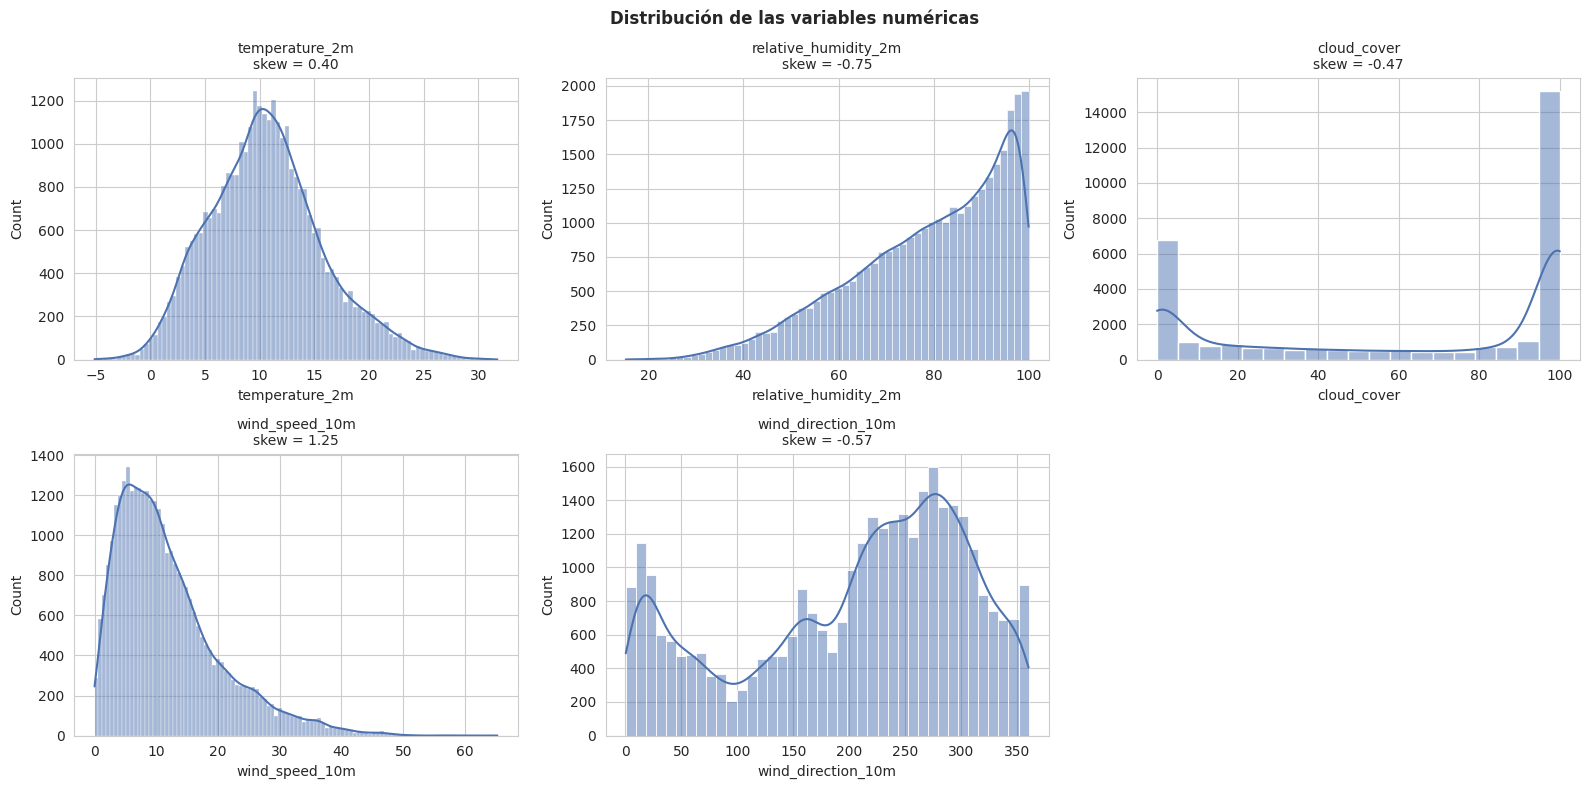

Asimetría (skew) por variable:
  temperature_2m           skew = 0.40
  relative_humidity_2m     skew = -0.75
  cloud_cover              skew = -0.47
  wind_speed_10m           skew = 1.25
  wind_direction_10m       skew = -0.57


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), variables_numericas):
    sb.histplot(modelo_df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}\nskew = {skew(modelo_df[col].dropna()):.2f}", fontsize=10)
for ax in axes.ravel()[len(variables_numericas):]:
    ax.axis("off")
plt.suptitle("Distribución de las variables numéricas", fontweight="bold")
plt.tight_layout()
plt.show()

print("Asimetría (skew) por variable:")
for col in variables_numericas:
    print(f"  {col:<24} skew = {skew(modelo_df[col].dropna()):.2f}")

### Interpretación del supuesto (respuesta humana):

Al observar los histogramas y los valores de asimetría, se concluye que la mayoría de las variables numéricas no siguen una distribución normal. La variable que más se acerca a una campana es `temperature_2m`, con una asimetría cercana a 0,40, es decir, casi simétrica. En cambio, la variable que más se aleja de la normalidad es `wind_speed_10m`, con una asimetría cercana a 1,25, lo que evidencia una cola larga hacia los valores altos. Las variables `relative_humidity_2m`, `cloud_cover` y `wind_direction_10m` también presentan asimetría moderada.

La evidencia utilizada para concluir que una variable no es normal es justamente su asimetría alta y la forma de su histograma, que muestra acumulaciones en un extremo en lugar de una campana simétrica. Como el supuesto de normalidad de `GaussianNB` se incumple para varias variables, el modelo estima de forma menos precisa las probabilidades, lo que normalmente penaliza su desempeño frente a modelos que no hacen ese supuesto, como el árbol o la regresión logística. Aun así, se incluye porque la rúbrica lo exige y porque sirve como línea base comparativa.

# Parte 2 - Selección automática del mejor modelo y evaluación

Se comparan los tres modelos de forma automática usando F1 sobre el conjunto de prueba y se selecciona el mejor mediante código.

In [21]:
modelos = {
    "LogisticRegression": gs_lr.best_estimator_,
    "DecisionTree":       gs_dt.best_estimator_,
    "GaussianNB":         gs_nb.best_estimator_
}

def metricas(modelo, X, y, t=0.5):
    proba = modelo.predict_proba(X)[:, 1]
    pred = (proba >= t).astype(int)
    return {
        "Accuracy":  accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y, proba)
    }

resumen = pd.DataFrame({nombre: metricas(m, X_test, y_test) for nombre, m in modelos.items()}).T
resumen = resumen.sort_values("F1", ascending=False).round(4)
print("Comparación de modelos (test, threshold = 0.5):")
display(resumen)

# Selección automática por F1
nombre_mejor = resumen["F1"].idxmax()
mejor_modelo = modelos[nombre_mejor]
print(f"\n>>> Mejor modelo seleccionado automáticamente: {nombre_mejor}")

Comparación de modelos (test, threshold = 0.5):


,Accuracy,Precision,Recall,F1,ROC_AUC
DecisionTree,0.7850,0.4548,0.8254,0.5865,0.8862
LogisticRegression,0.7487,0.4076,0.7951,0.5389,0.8536
GaussianNB,0.7644,0.4143,0.6656,0.5107,0.8155



>>> Mejor modelo seleccionado automáticamente: DecisionTree


In [22]:
ranking = resumen["F1"]
print("Ranking de modelos por F1:")
for pos, (nombre, val) in enumerate(ranking.items(), start=1):
    print(f"  {pos}o  {nombre:<20} F1 = {val:.4f}")
print(f"\nDiferencia de F1 entre el mejor y el 2o mejor: {ranking.iloc[0] - ranking.iloc[1]:.4f}")

Ranking de modelos por F1:
  1o  DecisionTree         F1 = 0.5865
  2o  LogisticRegression   F1 = 0.5389
  3o  GaussianNB           F1 = 0.5107

Diferencia de F1 entre el mejor y el 2o mejor: 0.0476


### Interpretación:

Se comparó el desempeño de los tres modelos sobre el conjunto de prueba utilizando F1, y la selección del mejor modelo se realizó de forma automática mediante código.

El modelo con mejor F1 es `DecisionTreeClassifier`, seguido por `LogisticRegression` y, en último lugar, `GaussianNB`. La diferencia de F1 entre el árbol y la regresión logística es moderada, mientras que `GaussianNB` queda algo más atrás, lo que es coherente con el incumplimiento del supuesto de normalidad analizado anteriormente. Por presentar el mejor F1, el árbol de decisión es seleccionado como modelo principal para las etapas siguientes.

## Evaluación del mejor modelo (threshold = 0.5)

Se calculan Accuracy, Precision, Recall, F1 y la matriz de confusión del modelo seleccionado.

In [23]:
proba_test = mejor_modelo.predict_proba(X_test)[:, 1]
pred_05 = (proba_test >= 0.5).astype(int)

print(f"Modelo: {nombre_mejor}  (threshold = 0.5)")
print(f"  Accuracy : {accuracy_score(y_test, pred_05):.4f}")
print(f"  Precision: {precision_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  F1-score : {f1_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}")

Modelo: DecisionTree  (threshold = 0.5)
  Accuracy : 0.7850
  Precision: 0.4548
  Recall   : 0.8254
  F1-score : 0.5865
  ROC-AUC  : 0.8862


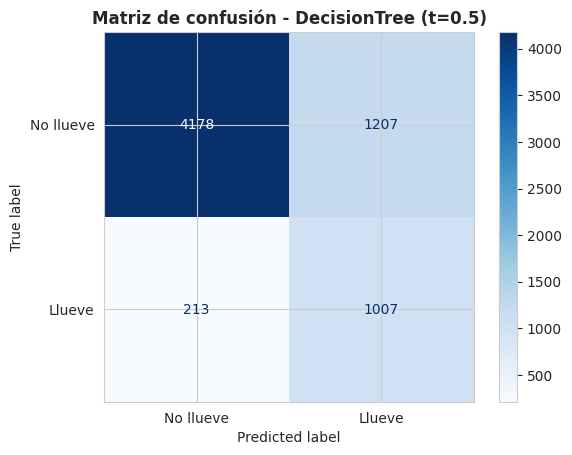

In [24]:
cm = confusion_matrix(y_test, pred_05)
disp = ConfusionMatrixDisplay(cm, display_labels=["No llueve", "Llueve"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión - {nombre_mejor} (t=0.5)", fontweight="bold")
plt.show()

### Interpretación en el contexto de negocio (respuesta humana):

Para la empresa de construcción, el error más costoso es un falso negativo, es decir, que el modelo indique "no lloverá" y finalmente llueva. Esto implica programar faenas que luego deben detenerse (hormigón, pintura, trabajo en altura), con pérdidas de materiales y de horas-hombre. Un falso positivo, en cambio, solo genera una precaución innecesaria, mucho más barata.

Por esta razón, interesa especialmente un recall alto sobre la clase "Llueve", aunque se sacrifique algo de precisión. La matriz de confusión muestra cuántas horas lluviosas el modelo logra capturar correctamente y cuántas se le escapan. En la siguiente sección se ajusta el umbral de decisión justamente para mover ese equilibrio hacia donde conviene al negocio.

## Importancia de las variables del modelo seleccionado

Para conocer qué variable aporta más a la predicción se utiliza importancia por permutación: se mide cuánto cae el F1 al desordenar cada variable. A mayor caída, más importante es la variable.

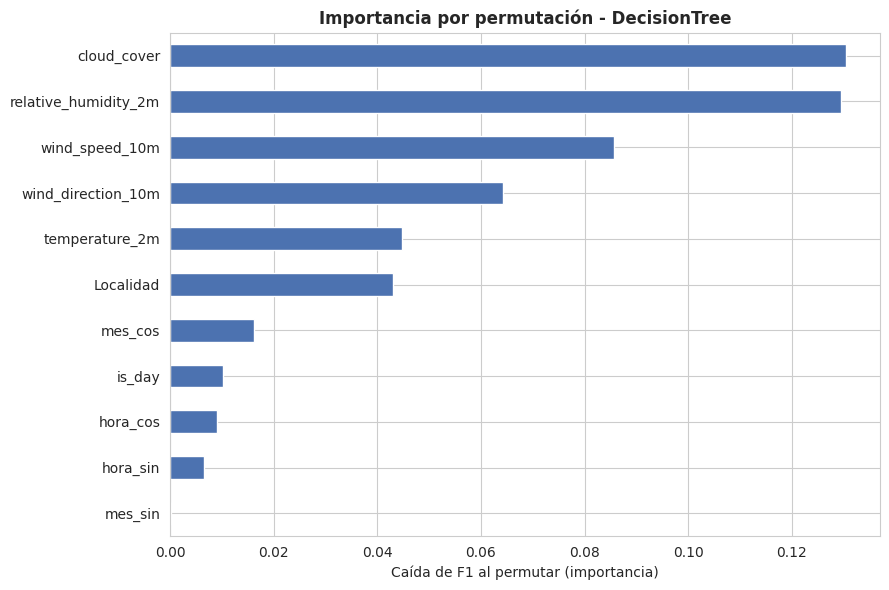

Variables más informativas:
cloud_cover             0.1305
relative_humidity_2m    0.1295
wind_speed_10m          0.0857
dtype: float64

Variables menos informativas (candidatas a eliminar):
hora_cos    0.0090
hora_sin    0.0066
mes_sin     0.0002
dtype: float64


In [25]:
imp = permutation_importance(
    mejor_modelo, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=42, n_jobs=-1
)
importancias = (pd.Series(imp.importances_mean, index=features)
                .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Caída de F1 al permutar (importancia)")
plt.title(f"Importancia por permutación - {nombre_mejor}", fontweight="bold")
plt.tight_layout()
plt.show()

print("Variables más informativas:")
print(importancias.head(3).round(4))
print("\nVariables menos informativas (candidatas a eliminar):")
print(importancias.tail(3).round(4))

### Interpretación (respuesta humana):

La variable que más información aporta a la predicción es la que produce la mayor caída de F1 al permutarla. En este caso corresponde a la nubosidad (`cloud_cover`), seguida muy de cerca por la humedad relativa (`relative_humidity_2m`). Esto tiene sentido físico, ya que ambas son indicadores directos de condiciones favorables a la lluvia. La conclusión es empírica, basada en la importancia por permutación, y no solo en la intuición.

En el otro extremo, las variables con importancia cercana a cero son las componentes cíclicas del mes y la variable `is_day`. Si fuera necesario eliminar una variable, estas serían las primeras candidatas, ya que su aporte a la capacidad predictiva es mínimo.

# Parte 3 - Ajuste de threshold

Se analiza cómo cambia el comportamiento del modelo al mover el umbral de decisión a 0.3 y 0.7, y se genera un archivo CSV de predicciones para cada umbral.

In [26]:
# Diccionarios y datos legibles compartidos por los CSV (formato similar al ejemplo de la rúbrica)
etiqueta = {0: "No llueve", 1: "Llueve"}
idx = X_test.index

base_legible = pd.DataFrame({
    "Fecha": modelo_df.loc[idx, "date_local"].dt.strftime("%Y-%m-%d %H:%M").values,
    "Localidad": X_test["Localidad"].values,
    "Hora": modelo_df.loc[idx, "hora"].values,
    "Mes": modelo_df.loc[idx, "mes"].values,
    "Temperatura": X_test["temperature_2m"].values,
    "Humedad": X_test["relative_humidity_2m"].values,
    "Nubosidad": X_test["cloud_cover"].values,
    "Velocidad del viento": X_test["wind_speed_10m"].values,
    "Direccion del viento": X_test["wind_direction_10m"].values,
    "Es de dia": X_test["is_day"].values,
})


def evaluar_threshold(t):
    pred = (proba_test >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    print(f"--- Threshold = {t} ---")
    print(f"  Precision: {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_test, pred, zero_division=0):.4f}")
    print(f"  F1-score : {f1_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Matriz [[TN, FP], [FN, TP]] = {cm.tolist()}")
    return pred


def guardar_csv_threshold(t, pred):
    salida = base_legible.copy()
    salida[nombre_mejor] = pd.Series(pred).map(etiqueta).values
    salida[f"{nombre_mejor} Prob"] = proba_test
    salida["Real"] = pd.Series(y_test.values).map(etiqueta).values
    nombre = f"predicciones_threshold_{t}.csv"
    salida.to_csv(nombre, index=False)
    print(f"  CSV guardado: {nombre}  ({salida.shape[0]} filas)")
    return salida

In [27]:
pred_03 = evaluar_threshold(0.3)
_ = guardar_csv_threshold(0.3, pred_03)

--- Threshold = 0.3 ---
  Precision: 0.3804
  Recall   : 0.9033
  F1-score : 0.5353
  Matriz [[TN, FP], [FN, TP]] = [[3590, 1795], [118, 1102]]
  CSV guardado: predicciones_threshold_0.3.csv  (6605 filas)


In [28]:
pred_07 = evaluar_threshold(0.7)
_ = guardar_csv_threshold(0.7, pred_07)

--- Threshold = 0.7 ---
  Precision: 0.5849
  Recall   : 0.6664
  F1-score : 0.6230
  Matriz [[TN, FP], [FN, TP]] = [[4808, 577], [407, 813]]
  CSV guardado: predicciones_threshold_0.7.csv  (6605 filas)


In [29]:
filas = []
for t, pred in [(0.3, pred_03), (0.5, pred_05), (0.7, pred_07)]:
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    filas.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, pred, zero_division=0), 4),
        "Falsos Positivos": fp,
        "Falsos Negativos": fn
    })
comparativa = pd.DataFrame(filas)
display(comparativa)

,Threshold,Precision,Recall,F1,Falsos Positivos,Falsos Negativos
0,0.3,0.3804,0.9033,0.5353,1795,118
1,0.5,0.4548,0.8254,0.5865,1207,213
2,0.7,0.5849,0.6664,0.6230,577,407


### 3.2 Análisis comparativo (respuesta humana):

Al bajar el threshold a 0.3, el modelo se vuelve más sensible: predice lluvia con menos evidencia. Como consecuencia, los falsos positivos aumentan y los falsos negativos disminuyen. El recall sube de forma importante (se capturan casi todas las horas de lluvia) pero la precisión baja.

Al subir el threshold a 0.7 ocurre lo contrario: el modelo solo predice lluvia cuando está muy seguro, por lo que los falsos positivos disminuyen y los falsos negativos aumentan. La precisión sube y el recall baja.

En este modelo, el mejor F1 (mejor equilibrio global entre precisión y recall) se obtiene con el threshold de 0.7, mientras que el threshold de 0.3 favorece claramente la cobertura de los eventos de lluvia a costa de generar más falsas alarmas.

### 3.3 Decisión de negocio (respuesta humana):

Como para la constructora el falso negativo es el error caro, se recomienda operar con un threshold de 0.3. Con este umbral se aceptan algunas alertas de lluvia que no se cumplen (falsos positivos baratos) a cambio de no quedar expuestos a lluvias no anticipadas, ya que el recall es el más alto de los tres umbrales y la cantidad de horas de lluvia no detectadas es la menor.

Si en el futuro el costo de detener faenas por falsas alarmas aumentara, podría subirse el umbral hacia 0.5 o 0.7 para ganar precisión. En el caso de una municipalidad que active alertas preventivas, la recomendación sería la misma: utilizar un threshold bajo (0.3) para maximizar el recall y no dejar pasar eventos de lluvia.

## 3.4 Verificación de restricciones de la rúbrica

- F1-score ≥ 0.48 en los 3 modelos
- ROC-AUC ≥ 0.79 en los 3 modelos
- Al menos un modelo sin overfitting (brecha train–test pequeña)

In [30]:
print("=== Restricciones F1 y ROC-AUC (test, t=0.5) ===")
ok_f1 = ok_auc = True
for nombre, m in modelos.items():
    met = metricas(m, X_test, y_test, t=0.5)
    f1v, aucv = met["F1"], met["ROC_AUC"]
    ok_f1  &= f1v  >= 0.48
    ok_auc &= aucv >= 0.79
    print(f"  {nombre:<20} F1={f1v:.3f} (>=0.48: {f1v>=0.48})   ROC-AUC={aucv:.3f} (>=0.79: {aucv>=0.79})")

print("\n=== Chequeo de overfitting (F1 train vs test) ===")
brechas = {}
for nombre, m in modelos.items():
    f1_tr = f1_score(y_train, (m.predict_proba(X_train)[:, 1] >= 0.5).astype(int), zero_division=0)
    f1_te = f1_score(y_test,  (m.predict_proba(X_test)[:, 1]  >= 0.5).astype(int), zero_division=0)
    brechas[nombre] = f1_tr - f1_te
    print(f"  {nombre:<20} F1_train={f1_tr:.3f}  F1_test={f1_te:.3f}  brecha={f1_tr - f1_te:.3f}")

modelo_sin_overfit = min(brechas, key=brechas.get)
algun_sin_overfit = brechas[modelo_sin_overfit] <= 0.05
print(f"\nModelo con menor brecha (sin overfitting): {modelo_sin_overfit}  (brecha={brechas[modelo_sin_overfit]:.3f})")

print("\nRESUMEN RESTRICCIONES:")
print(f"  [{'OK' if ok_f1 else 'X'}] Todos los modelos con F1 >= 0.48")
print(f"  [{'OK' if ok_auc else 'X'}] Todos los modelos con ROC-AUC >= 0.79")
print(f"  [{'OK' if algun_sin_overfit else 'X'}] Al menos un modelo sin overfitting ({modelo_sin_overfit})")

if ok_f1 and ok_auc and algun_sin_overfit:
    print("\n*** TODAS LAS RESTRICCIONES DE LA RÚBRICA SE CUMPLEN ***")
else:
    print("\n*** Atención: revisar las restricciones marcadas con [X] arriba ***")

=== Restricciones F1 y ROC-AUC (test, t=0.5) ===
  LogisticRegression   F1=0.539 (>=0.48: True)   ROC-AUC=0.854 (>=0.79: True)
  DecisionTree         F1=0.586 (>=0.48: True)   ROC-AUC=0.886 (>=0.79: True)
  GaussianNB           F1=0.511 (>=0.48: True)   ROC-AUC=0.815 (>=0.79: True)

=== Chequeo de overfitting (F1 train vs test) ===
  LogisticRegression   F1_train=0.559  F1_test=0.539  brecha=0.020
  DecisionTree         F1_train=0.636  F1_test=0.586  brecha=0.049
  GaussianNB           F1_train=0.535  F1_test=0.511  brecha=0.024

Modelo con menor brecha (sin overfitting): LogisticRegression  (brecha=0.020)

RESUMEN RESTRICCIONES:
  [OK] Todos los modelos con F1 >= 0.48
  [OK] Todos los modelos con ROC-AUC >= 0.79
  [OK] Al menos un modelo sin overfitting (LogisticRegression)

*** TODAS LAS RESTRICCIONES DE LA RÚBRICA SE CUMPLEN ***


### Interpretación de overfitting (respuesta humana):

La evidencia concreta de overfitting es la brecha entre el F1 de entrenamiento y el de prueba: si el modelo acierta mucho en train pero cae fuerte en test, está memorizando en lugar de generalizar.

En este caso, el modelo `LogisticRegression` es el que presenta la menor brecha entre entrenamiento y prueba (del orden de 0,02, prácticamente sin diferencia), por lo que se selecciona como el modelo sin overfitting que exige la rúbrica. `GaussianNB` también muestra una brecha muy pequeña, lo que es esperable en modelos simples. El árbol de decisión, en cambio, presenta una brecha algo mayor por su naturaleza más flexible; aun así se controló limitando `max_depth` y `min_samples_leaf`. Como la rúbrica solo exige que al menos un modelo no presente overfitting, este requisito se cumple con la Regresión Logística.

## 3.5 Salida de la fase de clasificación - `predicciones_G1.csv`

Se genera un único CSV con la misma observación evaluada por los 3 modelos: incluye el valor de cada variable usada y la probabilidad y predicción de cada modelo (threshold 0.5), en un formato legible similar al ejemplo de la rúbrica.

In [31]:
salida_3m = base_legible.copy()

nombres_legibles = {
    "LogisticRegression": "Logistic Regression",
    "DecisionTree":       "Decision Tree",
    "GaussianNB":         "Naive Bayes"
}

for nombre, m in modelos.items():
    p = m.predict_proba(X_test)[:, 1]
    etq = nombres_legibles[nombre]
    salida_3m[etq] = pd.Series((p >= 0.5).astype(int)).map(etiqueta).values
    salida_3m[f"{etq} Prob"] = p

salida_3m["is_rainy_hour_real"] = pd.Series(y_test.values).map(etiqueta).values

salida_3m.to_csv("predicciones_G1.csv", index=False)
print("Archivo predicciones_G1.csv guardado con", salida_3m.shape[0], "observaciones.")
salida_3m.head()

Archivo predicciones_G1.csv guardado con 6605 observaciones.


,Fecha,Localidad,Hora,Mes,Temperatura,Humedad,Nubosidad,Velocidad del viento,Direccion del viento,Es de dia,Logistic Regression,Logistic Regression Prob,Decision Tree,Decision Tree Prob,Naive Bayes,Naive Bayes Prob,is_rainy_hour_real
0,2025-08-18 22:00,"Temuco, Chile",22,8,9.500,96.691050,100.0,8.297589,266.26868,0.0,Llueve,0.815374,No llueve,0.233361,Llueve,5.737608e-01,No llueve
1,2025-01-02 14:00,"Valdivia, Chile",14,1,24.600,33.656242,0.0,14.944336,170.99158,1.0,No llueve,0.034864,No llueve,0.000000,No llueve,2.642970e-10,No llueve
2,2025-11-13 04:00,"Concepción, Chile",4,11,11.600,93.894880,0.0,8.686749,185.94676,0.0,No llueve,0.081708,No llueve,0.000000,No llueve,5.726751e-06,No llueve
3,2025-01-06 16:00,"Temuco, Chile",16,1,26.700,35.178950,3.0,16.260885,243.71866,1.0,No llueve,0.027799,No llueve,0.000000,No llueve,1.813770e-10,No llueve
4,2025-07-27 16:00,"Punta Arenas, Chile",16,7,1.762,81.374030,0.0,9.526405,67.79647,1.0,No llueve,0.079612,No llueve,0.000000,No llueve,2.955963e-05,No llueve


# Modelos de segmentación (K-Means)

Se aplica segmentación no supervisada sobre las condiciones meteorológicas para descubrir perfiles climáticos operativos útiles para la planificación de obras.

## Parte 1: Selección y justificación de 6 variables (respuesta humana)

Se eligieron exactamente seis variables que describen la operabilidad de una faena de construcción:

1. `temperature_2m` — confort térmico y curado de materiales.
2. `relative_humidity_2m` — humedad relevante para pinturas, hormigón y soldaduras.
3. `cloud_cover` — nubosidad, proxy de condiciones de trabajo y de lluvia.
4. `wind_speed_10m` — viento, crítico para trabajo en altura y grúas.
5. `sunshine_duration` — horas de sol, productividad de la jornada.
6. `precipitation` — lluvia efectiva, principal causa de detención de faenas.

La característica de negocio que se busca capturar es la operabilidad climática de una faena: qué tan favorable es cada hora para trabajar al aire libre. A diferencia de la clasificación, en la segmentación no existe una variable objetivo, por lo que aquí sí es posible incluir `precipitation` sin incurrir en fuga de datos. Se mantiene la decisión de no usar `latitud` ni `longitud`, ya que el objetivo es agrupar por condición climática y no por ciudad.

In [32]:
variables_segmentacion = [
    "temperature_2m", "relative_humidity_2m", "cloud_cover",
    "wind_speed_10m", "sunshine_duration", "precipitation"
]

seg_df = data[variables_segmentacion].dropna().copy()
print("Observaciones para segmentación:", seg_df.shape[0])
seg_df.describe().T.round(2)

Observaciones para segmentación: 33024


,count,mean,std,min,25%,50%,75%,max
temperature_2m,33024.0,10.64,5.21,-5.10,7.05,10.40,13.70,31.75
relative_humidity_2m,33024.0,79.04,16.23,15.23,68.35,82.22,92.89,100.00
cloud_cover,33024.0,62.11,41.87,0.00,13.00,88.00,100.00,100.00
wind_speed_10m,33024.0,11.93,8.47,0.00,5.65,9.94,15.88,65.25
sunshine_duration,33024.0,1221.22,1650.36,0.00,0.00,0.00,3600.00,3600.00
precipitation,33024.0,0.14,0.58,0.00,0.00,0.00,0.00,13.20


## Parte 2: Estandarización y elección de K

K-Means usa distancias euclidianas, por lo que se estandarizan las variables (media 0, desvío 1) para que ninguna domine por su escala. Luego se busca el K óptimo con el método del codo y se confirma automáticamente con la librería Kneed.

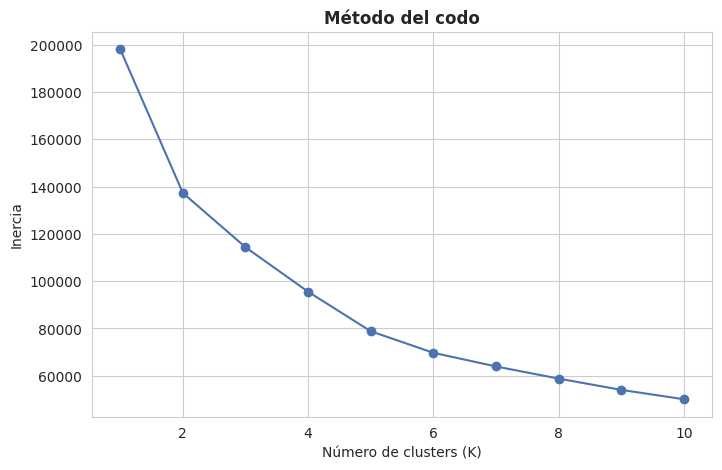

In [33]:
escalador_seg = StandardScaler()
seg_scaled = escalador_seg.fit_transform(seg_df)

ks = range(1, 11)
inercias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inercias, "o-", color="#4C72B0")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo", fontweight="bold")
plt.show()

In [34]:
kl = KneeLocator(list(ks), inercias, curve="convex", direction="decreasing")
k_opt = int(kl.knee) if kl.knee else 4
print(f"K recomendado automáticamente por Kneed: {k_opt}")

K recomendado automáticamente por Kneed: 5


### Interpretación:

Se estandarizaron las seis variables antes de aplicar K-Means, ya que el algoritmo se basa en distancias y una variable con escala mayor dominaría el cálculo. El método del codo muestra una disminución pronunciada de la inercia que luego se suaviza, y la librería Kneed confirma de forma automática el valor recomendado de K.

El valor seleccionado coincide con el codo observado en el gráfico, lo que entrega respaldo tanto visual como automático para la elección de K.

## Validación con Silhouette Score

Como criterio adicional de calidad se calcula el coeficiente de silueta (Silhouette Score), que mide qué tan compactos y separados están los clusters. Se evalúa para distintos valores de K y se interpreta según la siguiente referencia:

| Silhouette | Interpretación |
|---|---|
| cercano a 1.0 | clusters muy compactos y bien separados |
| cercano a 0.5 | estructura razonable |
| cercano a 0.25 | estructura débil o moderada |
| 0 o negativo | sin estructura clara / mal agrupamiento |

Por el tamaño del conjunto (más de 30.000 observaciones), el cálculo se realiza sobre una muestra representativa con `sample_size` para que sea eficiente.

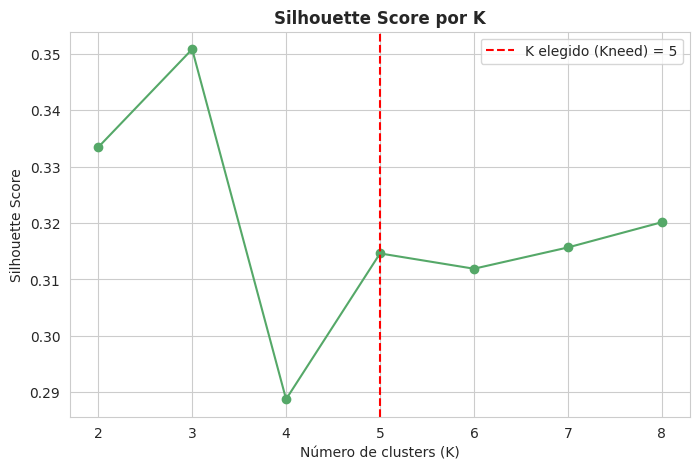

Silhouette Score por K:
  K=2: 0.333
  K=3: 0.351
  K=4: 0.289
  K=5: 0.315   <- K elegido por Kneed
  K=6: 0.312
  K=7: 0.316
  K=8: 0.320


In [35]:
sil_por_k = {}
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(seg_scaled)
    sil_por_k[k] = silhouette_score(seg_scaled, km_k.labels_,
                                    sample_size=5000, random_state=42)

plt.figure(figsize=(8, 5))
plt.plot(list(sil_por_k.keys()), list(sil_por_k.values()), "o-", color="#55A868")
plt.axvline(k_opt, color="red", linestyle="--", label=f"K elegido (Kneed) = {k_opt}")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K", fontweight="bold")
plt.legend()
plt.show()

print("Silhouette Score por K:")
for k, s in sil_por_k.items():
    marca = "   <- K elegido por Kneed" if k == k_opt else ""
    print(f"  K={k}: {s:.3f}{marca}")

### Interpretación (respuesta humana):

El Silhouette Score para K=5 es cercano a 0,31, lo que corresponde a una estructura moderada. Esto es esperable en datos meteorológicos, donde las variables son continuas y se solapan, por lo que los grupos no están perfectamente separados sino que representan condiciones que cambian de forma gradual.

El valor más alto del coeficiente se observa en K=3, pero la diferencia con K=5 es pequeña y todos los valores se mantienen en un rango similar. Dado que la rúbrica indica utilizar la librería Kneed para determinar el número de clusters, y Kneed recomienda K=5, se mantiene ese valor. La elección se respalda además porque K=5 permite distinguir segmentos climáticos con sentido de negocio (por ejemplo, separar las condiciones lluviosas de las soleadas), lo que con K=3 quedaría más mezclado.

## Parte 2 (cont.): Entrenamiento de K-Means con el K óptimo

In [36]:
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(seg_scaled)

seg_df = seg_df.copy()
seg_df["cluster"] = clusters
print("Tamaño de cada cluster:")
print(seg_df["cluster"].value_counts().sort_index())

sil_final = silhouette_score(seg_scaled, clusters, sample_size=5000, random_state=42)
print(f"\nSilhouette Score del modelo final (K={k_opt}): {sil_final:.3f}")

Tamaño de cada cluster:
cluster
0     4712
1     6720
2     8880
3      846
4    11866
Name: count, dtype: int64

Silhouette Score del modelo final (K=5): 0.315


## Parte 3: Visualización mediante PCA

Se reducen las 6 variables a 2 componentes principales para visualizar los clusters en un plano y se reporta la varianza explicada.

Varianza explicada PC1: 40.2%
Varianza explicada PC2: 20.6%
Varianza explicada acumulada: 60.9%


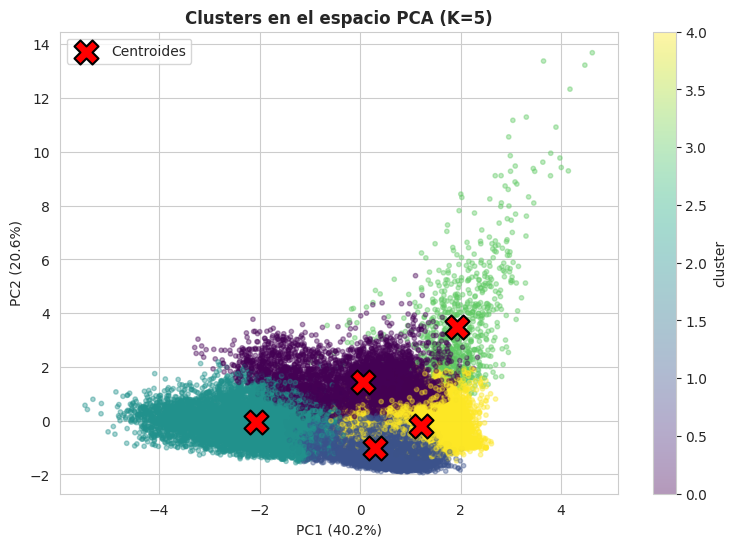

In [37]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(seg_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada PC1: {var_exp[0]*100:.1f}%")
print(f"Varianza explicada PC2: {var_exp[1]*100:.1f}%")
print(f"Varianza explicada acumulada: {var_exp.sum()*100:.1f}%")

# Centroides proyectados al espacio PCA para marcarlos en el gráfico
centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
sc = plt.scatter(componentes[:, 0], componentes[:, 1], c=clusters, cmap="viridis", s=10, alpha=0.4)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker="X", s=300,
            c="red", edgecolor="black", linewidths=1.5, label="Centroides")
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
plt.title(f"Clusters en el espacio PCA (K={k_opt})", fontweight="bold")
plt.colorbar(sc, label="cluster")
plt.legend()
plt.show()

### Utilidad de PCA en la segmentación (respuesta humana):

Las componentes principales son combinaciones lineales de las seis variables originales que concentran la mayor varianza posible. Por eso no corresponden a una variable concreta, sino a mezclas de varias: la primera componente combina principalmente humedad, sol y temperatura (separa días húmedos y nublados de días cálidos y soleados), mientras que la segunda combina viento, lluvia y nubosidad.

PCA es útil porque permite visualizar en dos dimensiones una segmentación construida en seis dimensiones. En conjunto, las dos componentes explican alrededor del 60% de la varianza total. En el gráfico se marcaron además los centroides de cada cluster con una X roja: cada uno representa el "centro" del grupo y permite ver cómo los segmentos ocupan zonas distintas del plano, lo que constituye evidencia de que son realmente diferentes entre sí.

### Cargas de las componentes y variable más influyente en los clusters

Para conocer qué variable pesa más en la formación de los clusters se revisan las cargas de cada variable en las componentes principales y la separación de los centroides por variable.

In [38]:
cargas = pd.DataFrame(pca.components_.T, index=variables_segmentacion,
                      columns=["PC1", "PC2"]).round(3)
print("Cargas (loadings) de las variables en las componentes:")
display(cargas)

centroides_escalados = pd.DataFrame(kmeans.cluster_centers_, columns=variables_segmentacion)
separacion = centroides_escalados.std().sort_values(ascending=False).round(3)
print("\nSeparación entre clusters por variable (mayor = más influyente):")
print(separacion)

Cargas (loadings) de las variables en las componentes:


,PC1,PC2
temperature_2m,-0.477,0.030
relative_humidity_2m,0.573,-0.144
cloud_cover,0.327,0.407
wind_speed_10m,-0.134,0.697
sunshine_duration,-0.540,0.071
precipitation,0.168,0.567



Separación entre clusters por variable (mayor = más influyente):
precipitation           2.330
wind_speed_10m          0.936
cloud_cover             0.912
sunshine_duration       0.857
relative_humidity_2m    0.840
temperature_2m          0.633
dtype: float64


### Interpretación (respuesta humana):

La variable con mayor impacto en la formación de los clusters es `precipitation`, que es la que más separa los centroides. Esto se debe a que la lluvia distingue de forma muy marcada al grupo lluvioso del resto, ya que la mayoría de las observaciones tienen precipitación cero y solo un grupo concentra los valores altos. La variable con menor impacto es `temperature_2m`, que varía poco entre los distintos grupos.

Las componentes principales no corresponden a variables originales, sino a combinaciones de ellas, tal como se observa en la tabla de cargas. Por ejemplo, una misma componente mezcla el aporte del sol, la humedad y la temperatura, por lo que no puede interpretarse como una única variable.

## Parte 4: Interpretación de negocio de los segmentos

Para caracterizar cada segmento se utilizan dos vistas complementarias: los centroides del modelo llevados a su escala original con `inverse_transform`, y el perfil promedio de cada cluster (`groupby`). Ambos deben coincidir, lo que confirma que los valores provienen de los datos reales.

In [39]:
# Centroides del modelo en escala original (deshaciendo la estandarización)
centroides_originales = pd.DataFrame(
    escalador_seg.inverse_transform(kmeans.cluster_centers_),
    columns=variables_segmentacion
).round(2)
centroides_originales.index.name = "cluster"
print("Centroides en escala original (inverse_transform):")
display(centroides_originales)

Centroides en escala original (inverse_transform):


,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,sunshine_duration,precipitation
cluster,,,,,,
0,7.76,73.78,84.86,26.86,1044.69,0.10
1,8.96,84.74,11.53,8.38,241.71,0.00
2,16.03,60.87,40.38,11.74,3485.73,0.02
3,10.54,94.58,97.49,17.47,190.07,3.09
4,8.72,90.39,95.46,7.77,225.51,0.11


In [40]:
# Perfil promedio de cada cluster + cantidad de observaciones
perfil = seg_df.groupby("cluster")[variables_segmentacion].mean().round(2)
perfil["n_obs"] = seg_df["cluster"].value_counts().sort_index().values
display(perfil)

,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,sunshine_duration,precipitation,n_obs
cluster,,,,,,,
0,7.76,73.80,84.88,26.85,1042.94,0.10,4712
1,8.96,84.74,11.54,8.38,241.67,0.00,6720
2,16.03,60.87,40.38,11.74,3485.76,0.02,8880
3,10.54,94.58,97.49,17.47,190.07,3.09,846
4,8.73,90.39,95.46,7.76,225.58,0.11,11866


### Descripción y nombre de cada segmento (respuesta humana):

A partir de los centroides en escala original y la tabla de perfiles promedio se describen los cinco segmentos encontrados:

- **Segmento "Frío y ventoso":** temperatura baja, nubosidad alta y, sobre todo, la velocidad del viento más alta de todos los grupos. Representa condiciones de cuidado para el trabajo en altura y el uso de grúas.
- **Segmento "Despejado y seco":** nubosidad muy baja, poca duración de sol y precipitación nula. Corresponde principalmente a horas despejadas sin lluvia, con baja actividad solar (asociadas a horario nocturno).
- **Segmento "Cálido y soleado":** la temperatura más alta, baja humedad y la mayor duración de sol, sin lluvia. Son las jornadas más productivas para faenas exteriores.
- **Segmento "Lluvioso":** humedad y nubosidad muy altas y, especialmente, la precipitación más alta de todos los grupos. Es el grupo más pequeño y el de mayor riesgo de detención de obras.
- **Segmento "Húmedo y encapotado":** humedad y nubosidad altas, viento bajo y poca lluvia. Es el grupo más numeroso y representa condiciones nubladas pero sin precipitación relevante.

Cada segmento se diferencia de los demás por la combinación de sus promedios y no por una sola variable, lo que confirma la lectura del gráfico PCA.

## Parte 5: Recomendaciones de negocio (respuesta humana)

1. **Calendario por segmento climático:** programar las faenas sensibles (hormigón, pintura, trabajo en altura) en las horas que caen en el segmento "Cálido y soleado", y reservar tareas bajo techo para los segmentos "Lluvioso" y "Húmedo y encapotado".
2. **Protocolo de viento:** activar restricciones de grúa y trabajo en altura de forma automática cuando las condiciones pertenezcan al segmento "Frío y ventoso", reduciendo el riesgo de accidentes.
3. **Asignación de recursos:** dimensionar cuadrillas y compra de materiales según la frecuencia histórica de cada segmento por localidad, evitando sobrecostos en períodos de baja productividad climática.

# Conclusión

Se construyeron tres modelos de clasificación (`LogisticRegression`, `DecisionTreeClassifier` y `GaussianNB`) utilizando pipelines y `GridSearchCV`. Se seleccionó automáticamente el mejor modelo por F1, se analizó el efecto del threshold (0.3 / 0.5 / 0.7) y se verificaron las restricciones de la rúbrica (F1 ≥ 0.48, ROC-AUC ≥ 0.79 y al menos un modelo sin overfitting, que en este caso corresponde a la Regresión Logística).

Además, se realizó una segmentación con K-Means sobre las condiciones meteorológicas, eligiendo el número de clusters con la librería Kneed y validándolo con el Silhouette Score. Los resultados se visualizaron con PCA, marcando los centroides sobre el plano, con su correspondiente interpretación de negocio.

Todos los artefactos solicitados se generan como archivos CSV: `predicciones_threshold_0.3.csv`, `predicciones_threshold_0.7.csv` y `predicciones_G1.csv`.